### Transformer
: Attention 블록을 여러 개 쌓고, 몇 가지 핵심 장치를 추가
- 구성 요소
    - Positional Encoding: "순서"를 어떻게 집어넣을 것인가
    - Multi-Head Attention: Attention을 왜 여러 개 병렬로 쓰는가
    - Feed-Forward Network: Attention 이후에 왜 MLP 층을 하나 더 붙이는가
    - Layer Normalization & Residual Connection: 학습을 안정시키는 두 장치
    - Enc - dec 전체 조립: 위 요소를 어떻게 쌓아올리는가

#### 1. Positional Encoding
Attention의 $QK^T$: 모든 단어 쌍을 동시에 계산하므로 "이 단어가 몇 번째 위치인지" 알 수 없음 <br>
ex) "나는 너를 사랑해"와 "너를 나는 사랑해"를 Self-Attention에 넣으면, 단어의 임베딩이 같다면 $QK^T$ 결과 또한 동일 - 단어 순서가 바뀌어도 Attention은 모름 <br>
    -> Positional Encoding으로 해결

해결책: 임베딩에 위치 정보 더하기 <br>
Transformer는 각 단어의 임베딩에 "이 단어가 몇 번째에 위치하는지"를 나타내는 벡터를 더함 <br>
$$ 입력 = 단어 임베딩 + Positional Encoding $$

위치 벡터는 $\sin / \cos$ 함수로 만듦 <br>
$$ PE_{(pos, 2i)} = \sin(\frac{pos}{10000^{\frac{2i}{dmodel}}}) $$
$$ PE_{(pos, 2i)} = \cos(\frac{pos}{10000^{\frac{2i}{dmodel}}}) $$

- $2i$: 벡터의 차원 인덱스
- $pos$: 단어의 위치
- $dmodel$: 임베딩 벡터의 차원 수

##### $\sin / \cos$ 함수 사용하는 이유
- 값이 항상 (-1, 1) 사이
    : 임베딩 값이 범위를 크게 벗어나지 않아 덧셈 후에도 임베딩 정보 손상이 없음
- 모든 위치가 고유한 패턴
    : $pos$가 달라지면 $\sin / \cos$ 값이 달라져 각 위치가 고유한 "지문(Fingerprint)"을 갖게 됨
- 상대적 위치 관계를 학습 가능
    : $\sin / \cos$의 덧셈 공식 ($\sin{a+b} = \sin a \cos b + \cos a \sin b$) 덕분에 위치 $pos + k$의 인코딩이 위치 $pos$의 인코딩의 선형 변환으로 표현될 수 있음
    즉, 모델이 "3번쨰 단어는 1번쨰 단어보다 2칸 뒤다"라는 상대적 거리 개념을 내적 연산으로 포착 가능

#### 2. Multi-Head Attention
Self-Attention 하나(1개의 $W_Q, W_K, W_V$)로는 한 가지 관점에서만 단어 관계를 볼 수 있음. <br>
하지만 언어는 동시에 여러 관점이 필요

$$ MultiHead(Q, K, V) = Concat(head_1, head_2, ..., head_H) \cdot W_o $$
- $각 Head = Attention({QW_Q}^{(h)}, {KW_K}^{(h)}, {VW_V}^{(h)})$
- $W_o$: Output 가중치 행렬

각 head는 다른 관점에서 단어 관계를 포착하고, 결과를 이어붙인 후 $W_o$으로 다시 하나의 벡터로 합침

ex) "The animal didn't cross the street it was tired"라는 문장에서 "it"을 처리할 때: <br>
    - 관점 1: 문법적 관계(it이 주어) <br>
    - 관점 2: 의미적 지시 대상(it이 animal을 지칭) <br>
    - 관점 3: 감정/상태 (tired와 연결)

Attention 하나로 세 가지를 동시에 잡기 어려움 -> Multi-Head Attention은 서로 다른 ${W_Q}^{(h)}, {W_K}^{(h)}, {W_V}^{(h)}$를 가진 Attention을 병렬로 계산

Q1. 관점이 많을수록 좋다면 Head의 개수를 많이 가져가는 게 좋은 것 아닐까? <br>
A1. Head의 개수가 많아지면 다양한 관점을 포착할 수 있다는 장점이 존재하지만, Head당 차원이 축소되어 표현력이 떨어지고($Head별 차원 = \frac{d_model}{차원 개수}$), 연산량이 증가한다는 트레이드오프가 존재
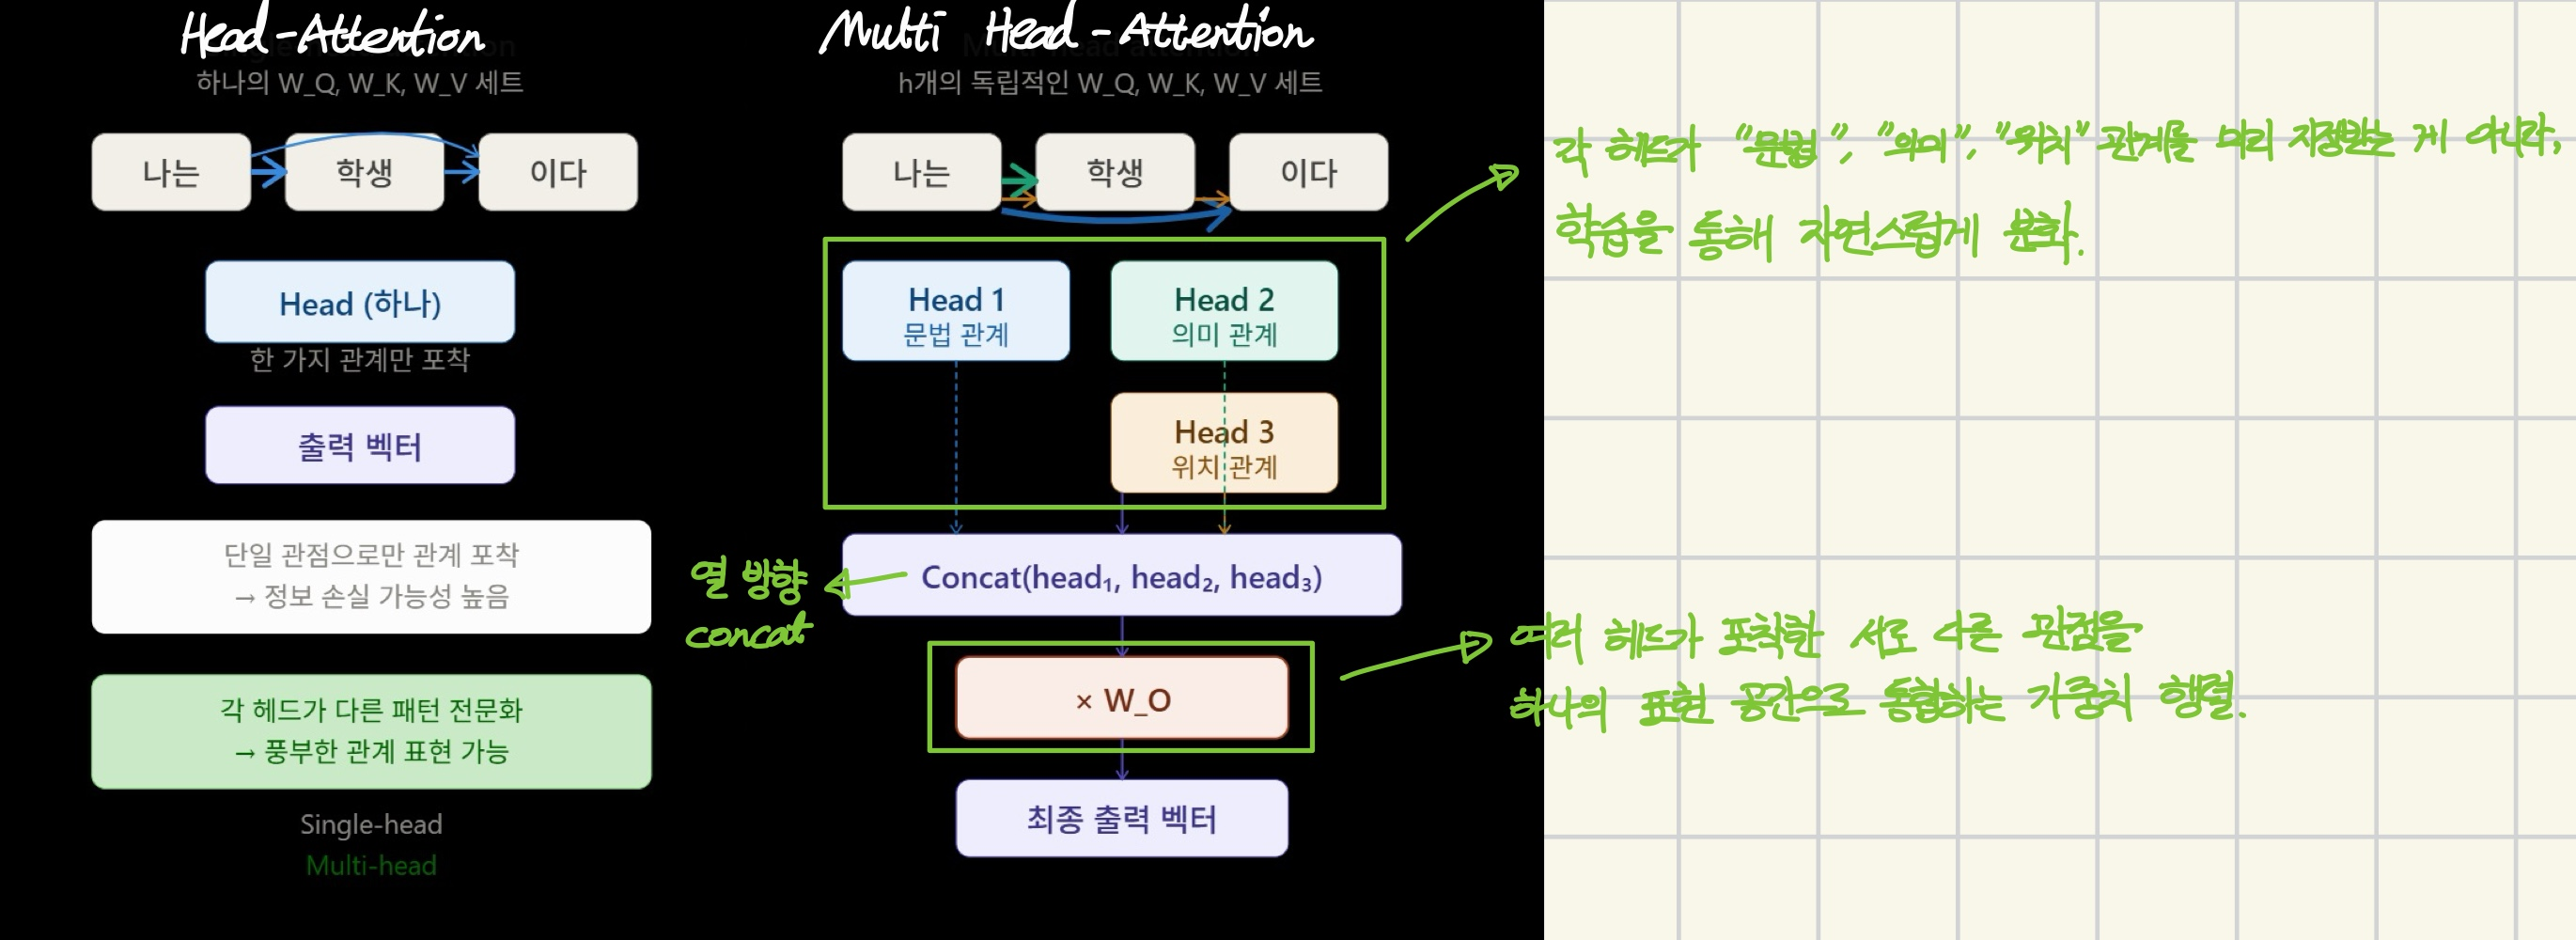

#### 3. Feed-Forward Network
Multi-Head Attention 이후 각 위치마다 독립적으로 적은 2층의 MLP를 통과
$$ FFN(x) = ReLU(xW_1 + b_1)W_2 + b_2 $$

사용하는 이유: Attention은 "어떤 단어를 얼마나 참조할지"를 결정하는 정보 수집 역할. FFN은 수집한 정보로 "실제 변환(비선형 처리)"을 수행하는 역할 -> 비선형 함수를 통해 표현력 부여

#### 4. Layer Normalization & Residual Connection
##### (1) Residual Connection (잔차 연결)
$$ 출력 = x + SubLayer(x) $$
입력 $x$를 SubLyaer(Attention or FFN)의 출력에 그대로 더함 -> LSTM의 Cell state 업데이트 식의 더하기와 같은 원리 <br>
수식을 미분하면 $ 1+f'(x)$ 형태로, 기울기가 0이 되더라도 1이 더해지기 때문에 소실을 방지함

##### (2) Layer Normalization
각 레이어의 출력을 평균 0, 분산 1로 정규화
$$ LayerNorm(x) = \frac{x - \mu}{\sigma + \epsilon} \cdot \gamma + B $$
-> 매 층마다 분포를 리셋해 학습 안정화(없으면 층이 깊어질수록 값의 분포가 달라져 학습이 불안정)

이 두 가지를 합치면 Transformer의 각 서브레이어는:
$$ 출력 = LayerNorm(x + SubLayer(x)) $$
이 구조로 Transformer가 수십 개의 레이어를 쌓아도 안정적으로 학습할 수 있음

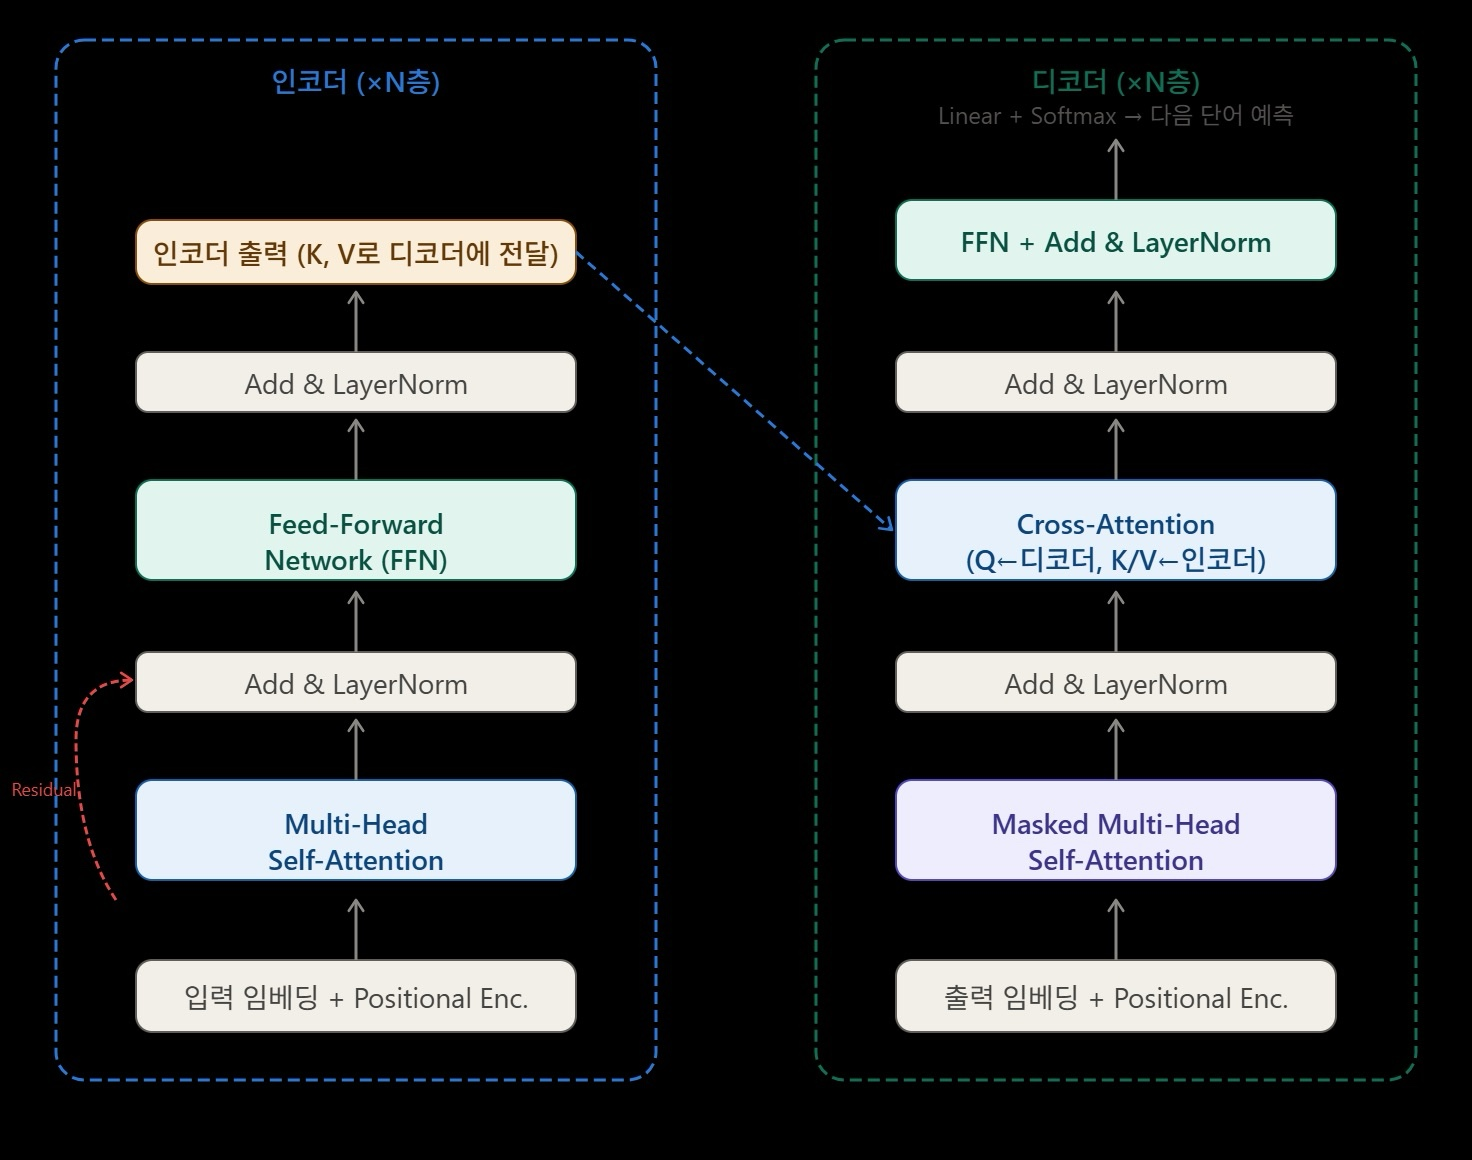

- 디코더에만 있는 "Masked" Multi-Head Attention
: "I go to school"을 생성하는 중이라면 "go"를 예측 시 아직 생성되지 않은 "to school"을 미리 보면 안됨. 그래서 $QK^T$ 행렬에서 현재 위치 이후의 값들을 $-\infty$로 마스킹해 Softmax 후 그 위치에 대한 Attention Weight가 0이 되도록 강제

- Cross-Attention
: Self-Attention은 Q, K, V 모두 같은 문장에서 오지만 Cross Attention은:
    - Q: 디코더의 현재 은닉 상태
    - K, V: 인코더의 출력 전체

    -> "지금 내가 생성하려는 단어(Q)가 입력 문장의 어느 부분(K)을 참조해야 하는지"를 매 시점마다 직접 계산 = Context Vector 하나로 입축이라는 병목을 해결

- 인코더와 디코더의 층 개수
: BERT의 경우 인코더만 12 또는 24층. 층이 많을수록 표현력이 올라가는데 Residual Connection 덕분에 깊이 쌓아도 학습이 안정적.

In [3]:
!pip install datasets transformers counter

  Preparing metadata (setup.py) ... done
  Created wheel for counter: filename=Counter-1.0.0-py3-none-any.whl size=5392 sha256=a8fb08a925b6d98e818d84fa4599298f332f6e699f57bd8b5199aac5c6c284e6
  Stored in directory: /root/.cache/pip/wheels/16/ff/7a/6e8bf2fdadb47c50a03bb4b9a59bd2b1da1b876faf8e3815d9
Successfully built counter


### 1. Subword Tokenizer 기반 데이터 파이프라인

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import math
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer
# from counter import Counter

# 1. 데이터셋 로드 (Rotten Tomatoes 영화 리뷰)
print("===Downloading dataset===")
raw_dataset = load_dataset("cornell-movie-review-data/rotten_tomatoes")

train_sentences = list(raw_dataset['train']['text'])
train_labels = list(raw_dataset['train']['label'])

# 2. 서브워드 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

class SubwordDataset(Dataset) :
    def __init__(self, sentences, labels, tokenizer, max_len = 128) :
        self.labels = labels

        # tokenizer를 직접 호출 시 서브워드 분절, 정수 인코딩, Padding, Truncation이 한 번에 처리됨
        self.encodings = tokenizer(
            sentences,
            max_length = max_len,
            padding = "max_length",
            truncation = True,
            return_tensors = "pt"
        )

    def __len__(self) :
        return len(self.labels)
    
    def __getitem__(self, idx) :
        # input_ids: 서브워드로 분절된 토큰들의 인덱스 순서
        return self.encodings['input_ids'][idx], torch.tensor(self.labels[idx])
    
max_sequence_len = 128
dataset = SubwordDataset(train_sentences, train_labels, tokenizer, max_len = max_sequence_len)
dataloader = DataLoader(dataset, batch_size = 32, shuffle = True)

# 서브워드 어휘 사전 정보 추출
vocab_size = tokenizer.vocab_size
PAD_IDX = tokenizer.pad_token_id

print(f"데이터셋 준비 완료. 서브워드 사전 크기(Vocab size): {vocab_size}")
print(f"패딩 토큰 인덱스(PAD_IDX): {PAD_IDX}")

# 서브워드 분절 예시 확인
example_text = "Transformer models use subword tokenization."
print(f"\n[토큰화 예시] 원문: {example_text}")
print(f"서브워드 분절: {tokenizer.tokenize(example_text)}")
print(f"정수 인코딩: {tokenizer.encode(example_text)}")

===Downloading dataset===
데이터셋 준비 완료. 서브워드 사전 크기(Vocab size): 30522
패딩 토큰 인덱스(PAD_IDX): 0

[토큰화 예시] 원문: Transformer models use subword tokenization.
서브워드 분절: ['transform', '##er', 'models', 'use', 'sub', '##word', 'token', '##ization', '.']
정수 인코딩: [101, 10938, 2121, 4275, 2224, 4942, 18351, 19204, 3989, 1012, 102]


### 2. Transformer 구조 구현

In [24]:
# Positional Encoding 설계
class PositionalEncoding(nn.Module) :
    def __init__(self, d_model, max_len = 512) :
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype = torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x) :
        return x + self.pe[:, :x.size(1)]

# Multi-Head Attention 설계    
class CustomMultiHeadAttention(nn.Module) :
    def __init__(self, d_model, n_heads) :
        super().__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v) :
        batch_size = q.size(0)
        Q = self.W_q(q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_probs = torch.softmax(scores, dim = -1)
        output = torch.matmul(attn_probs, V)

        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(output)

# Encoder 설계    
class CustomEncoderLayer(nn.Module) :
    def __init__(self, d_model, n_heads, d_ff) :
        super().__init__()
        self.attn = CustomMultiHeadAttention(d_model, n_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x) :
        x = self.norm1(x + self.attn(x, x, x))
        x = self.norm2(x + self.ffn(x))
        return x


class CustomTransformerClassifier(nn.Module) :
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, num_classes = 2) :
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([CustomEncoderLayer(d_model, n_heads, d_ff) for _ in range(n_layers)])
        self.fc_out = nn.Linear(d_model, num_classes)

    def forward(self, x) :
        x = self.embedding(x) * math.sqrt(x.size(-1))
        x = self.pos_encoder(x)
        for layer in self.layers :
            x = layer(x)
        x = x.mean(dim = 1) # Global Average Pooling
        return self.fc_out(x)
    
# 모델 생성
custom_model = CustomTransformerClassifier(vocab_size = vocab_size, d_model = 64, n_heads = 4, d_ff = 128, n_layers = 2)
print("===Ver 1: Subword 대응 Transformer 준비 완료===")

===Ver 1: Subword 대응 Transformer 준비 완료===


### 버전 2: PyTorch 빌트인 모듈 활용 구현

In [17]:
class PyTorchTransformerClassifier(nn.Module) :
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, num_classes = 2) :
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_ff, 
            batch_first=True,
            activation='relu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc_out = nn.Linear(d_model, num_classes)
        
    def forward(self, x):
        x = self.embedding(x) * math.sqrt(x.size(-1))
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        return self.fc_out(x)

# 모델 생성 (서브워드 사전 크기 주입)
builtin_model = PyTorchTransformerClassifier(vocab_size=vocab_size, d_model=64, n_heads=4, d_ff=128, n_layers=2)
print("버전 2: 서브워드 대응 PyTorch Built-in Transformer 준비 완료.")

버전 2: 서브워드 대응 PyTorch Built-in Transformer 준비 완료.


### 4. Subword 데이터셋으로 학습진행

In [25]:
def train_model(model, dataloader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        for src, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(src)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            predictions = outputs.argmax(dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
        print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(dataloader):.4f} | Accuracy: {correct/total*100:.2f}%")

print("\n=== [버전 1] 서브워드 기반 Custom Transformer 학습 ===")
train_model(custom_model, dataloader, epochs=3)

print("\n=== [버전 2] 서브워드 기반 PyTorch 내장 Transformer 학습 ===")
train_model(builtin_model, dataloader, epochs=3)


=== [버전 1] 서브워드 기반 Custom Transformer 학습 ===
Epoch 01 | Loss: 0.6821 | Accuracy: 55.91%
Epoch 02 | Loss: 0.6196 | Accuracy: 66.00%
Epoch 03 | Loss: 0.5577 | Accuracy: 71.36%

=== [버전 2] 서브워드 기반 PyTorch 내장 Transformer 학습 ===
Epoch 01 | Loss: 0.6827 | Accuracy: 55.77%
Epoch 02 | Loss: 0.6396 | Accuracy: 63.33%
Epoch 03 | Loss: 0.5939 | Accuracy: 68.36%


### 5. early-stopping을 포함한 학습 함수 구현

In [26]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.optim.lr_scheduler import ExponentialLR

def train_model_v2(model, dataloader, max_epochs=20, patience=3, lr_decay=0.8):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 1. 학습률 스케줄러 설정 (매 에폭마다 현재 학습률에 lr_decay를 곱함)
    scheduler = ExponentialLR(optimizer, gamma=lr_decay)
    
    # 시각화를 위한 기록용 딕셔너리
    history = {'loss': [], 'lr': []}
    
    # 조기 종료(Early Stopping)를 위한 변수 초기화
    best_loss = float('inf')
    patience_counter = 0
    
    # 2. 에폭 루프에 tqdm 적용
    epoch_progress = tqdm(range(max_epochs), desc=f"Training {model.__class__.__name__}")
    
    for epoch in epoch_progress:
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        # 현재 에폭 시작 시점의 학습률 기록
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        
        for src, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(src)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            predictions = outputs.argmax(dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
        avg_loss = total_loss / len(dataloader)
        accuracy = (correct / total) * 100
        
        # 기록 저장
        history['loss'].append(avg_loss)
        
        # 3. 매 에폭 종료 후 학습률 감소 반영
        scheduler.step()
        
        # tqdm 우측에 실시간 메트릭 표시
        epoch_progress.set_postfix({
            'Loss': f"{avg_loss:.4f}", 
            'Acc': f"{accuracy:.2f}%", 
            'LR': f"{current_lr:.6f}"
        })
        
        # 4. 조기 종료(Early Stopping) 논리 검증
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0  # 최저 loss 갱신 시 카운터 리셋
        else:
            patience_counter += 1 # loss가 줄지 않으면 카운트 증가
            if patience_counter >= patience:
                print(f"\n[Early Stopping] {epoch+1} 에폭에서 학습 조기 종료 (Loss가 {patience}회 동안 개선되지 않음)")
                break
                
    return history

#### 결과 시각화

In [27]:
def plot_training_history(history, title_name):
    epochs = range(1, len(history['loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Loss 하락 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'r-o', label='Train Loss')
    plt.title(f'{title_name} - Loss Trend', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--')
    plt.legend()
    
    # Learning Rate 감소 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['lr'], 'b-o', label='Learning Rate')
    plt.title(f'{title_name} - Learning Rate Decay', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('LR')
    plt.grid(True, linestyle='--')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


=== [버전 1] Custom Transformer 학습 시작 ===


Training CustomTransformerClassifier:   0%|          | 0/20 [00:00<?, ?it/s]

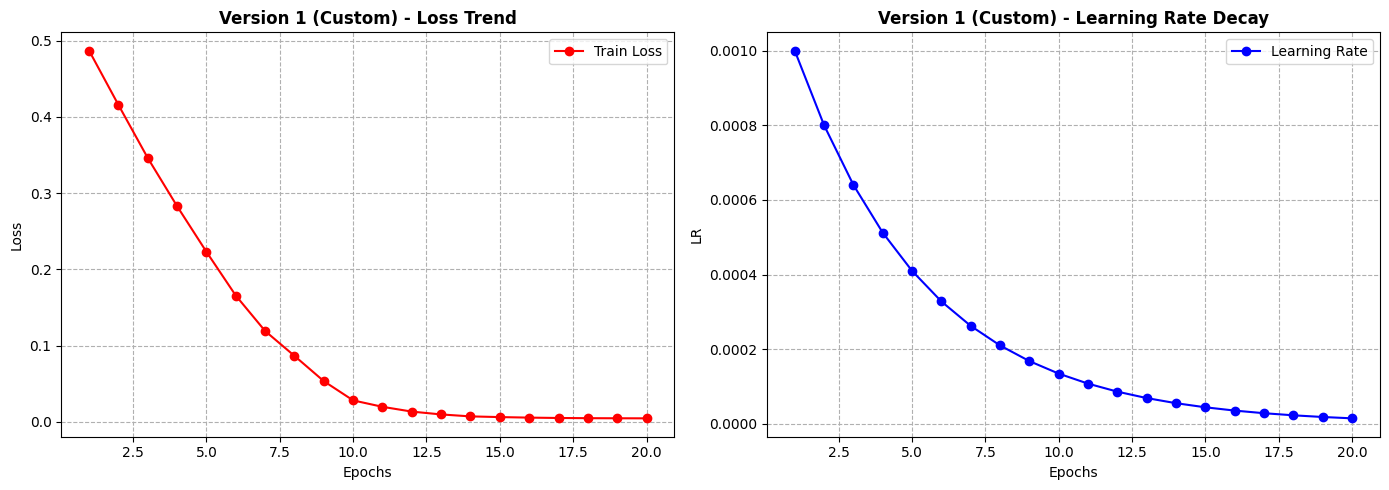


=== [버전 2] PyTorch Built-in Transformer 학습 시작 ===


Training PyTorchTransformerClassifier:   0%|          | 0/20 [00:00<?, ?it/s]

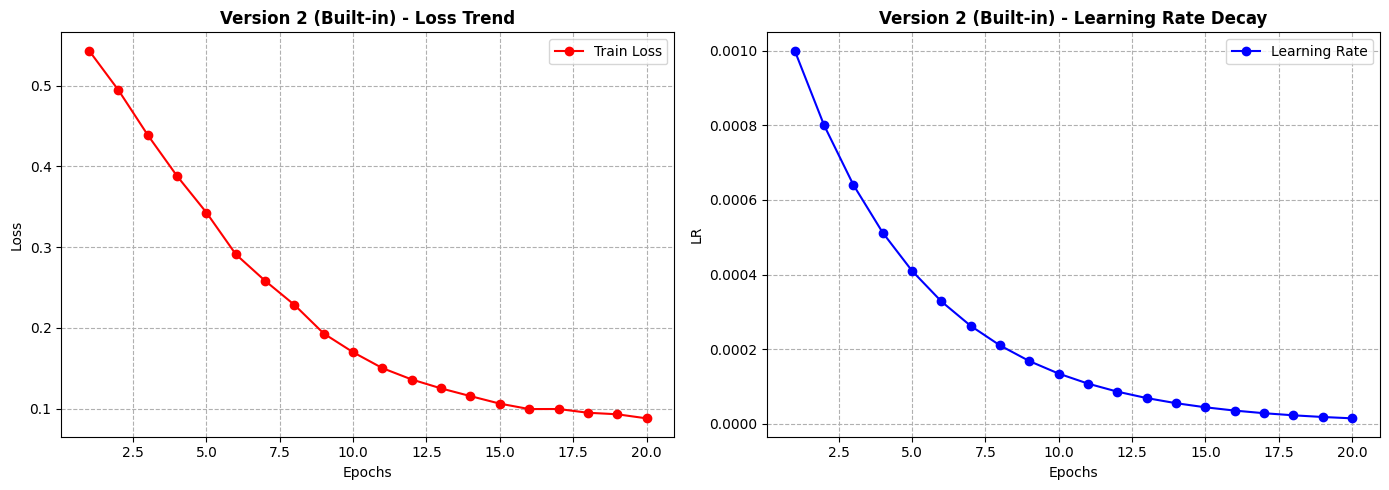

In [28]:
print("\n=== [버전 1] Custom Transformer 학습 시작 ===")
history_v1 = train_model_v2(custom_model, dataloader, max_epochs=20, patience=3, lr_decay=0.8)
plot_training_history(history_v1, "Version 1 (Custom)")

print("\n=== [버전 2] PyTorch Built-in Transformer 학습 시작 ===")
history_v2 = train_model_v2(builtin_model, dataloader, max_epochs=20, patience=3, lr_decay=0.8)
plot_training_history(history_v2, "Version 2 (Built-in)")